In [52]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx # we will use it for visualization
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from scipy.optimize import milp
from scipy import optimize
from scipy.sparse.csgraph import shortest_path

## Common parameters

Same problem parameters as Requirements 2 and 3 (defined once, before the environment).

In [53]:
# Problem parameters (same as Requirements 2 and 3)
n_campaigns = 3
n_users = 2000              # Number of rounds T
B = 300                     # Total budget
rho = B / n_users           # Budget per round

# Valuation of each campaign
my_valuations = np.array([0.6, 0.7, 0.8])

# Discrete set of possible bids
available_bids = np.linspace(0, 1, 11)

# Conflict graph (same as Requirement 2): campaigns 2 and 3 are mutually exclusive
conflict_edges = [(1, 2)]

t = np.arange(n_users)

print("Campaign valuations:", my_valuations)
print("Possible bids:", available_bids)
print("Budget per round:", rho)

Campaign valuations: [0.6 0.7 0.8]
Possible bids: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Budget per round: 0.15


## Slightly Non-stationary Environment (Requirement 4)
**Same generator, with $k_i(t)$ changing slowly.** Keep the uniform bidders and the same construction of the highest competing bid,
$$
m_i(t) = \max_{j=1,\dots,k_i(t)} u_{ij}(t), \qquad u_{ij}(t) \sim U(0,1), \qquad m_i(t) \sim \text{Beta}(k_i(t), 1),
$$
so the win probability of bid $b$ in campaign $i$ is again $b^{\,k_i(t)}$. What changes with respect to Requirement 3 is the *schedule* of $k_i(t)$: instead of cycling every few rounds, it is piecewise constant on a small number of long intervals. The horizon $[0, T)$ is partitioned by breakpoints $0 = \tau_0 < \tau_1 < \dots < \tau_P = T$ into $P$ phases, and inside phase $p$ the number of competitors is fixed:
$$
k_i(t) = k_i^{(p)} \quad \text{for } t \in [\tau_{p-1}, \tau_p), \qquad p = 1, \dots, P.
$$
With $T = 2000$ we use $P = 4$ phases with breakpoints $\tau = (0, 500, 1100, 1500, 2000)$ and
$$
k_1 = (1, 3, 2, 1), \qquad k_2 = (3, 1, 5, 2), \qquad k_3 = (5, 6, 1, 3).
$$
So:
1. in phase 1 (rounds $[0, 500)$) campaign 1 has 1 competitor and is the one worth bidding on, while campaigns 2 and 3 are hard ($k = 3$ and $k = 5$);
2. in phase 2 (rounds $[500, 1100)$) the roles switch: campaign 2 becomes the easy one ($k = 1$), campaign 1 gets harder ($k = 3$) and campaign 3 is essentially hopeless ($k = 6$);
3. in phase 3 (rounds $[1100, 1500)$) campaign 3 becomes the easy one ($k = 1$) while campaign 2 is the hardest ($k = 5$);
4. in phase 4 (rounds $[1500, 2000)$) campaign 1 is again the easy one ($k = 1$) and the others are moderately hard ($k = 2$ and $k = 3$).

The values are chosen with the same logic as in Requirement 3 (a campaign with $k = 1$ faces a mean competing bid of $0.5 < v_i$ and is *worth bidding*; a campaign with $k \ge 3$ faces a mean competing bid above $v_i$ and is *hard*), so in every phase a different campaign is the profitable one and both the optimal bid within a campaign and the optimal split of the budget across campaigns change at each breakpoint. The breakpoints are shared by all campaigns, so the change points are well-defined events. The phases have unequal lengths (500, 600, 400, 500 rounds) on purpose: a sliding window tuned to one phase length is not automatically right for the others.

Within a phase the environment is a proper stochastic bandit: $m_i(t)$ is i.i.d. $\text{Beta}(k_i^{(p)}, 1)$ for $t$ in the phase, with fixed win probabilities $b^{\,k_i^{(p)}}$. This is what makes the environment only *slightly* non-stationary: with phases of 400-600 rounds, a learner that forgets the past (sliding window) or resets when it detects a change (change detector) has enough time to re-estimate the means and behave near-optimally inside each phase, which is impossible in Requirement 3, where the phases last 10-30 rounds. As in Requirement 3, the sequence $k_i(t)$ is generated once with a fixed seed and then treated as given. In code it is the same `n_competitors_t` array, filled from the breakpoint list instead of `(t // L) % len(kappa)`, followed by the same `m_t` construction.

**Benchmark.** Because the phases are long, the natural benchmark is no longer the best *fixed* strategy in hindsight but the best *policy* in hindsight: a clairvoyant that knows the distribution of each phase. It solves the Requirement 2 LP once per phase, with that phase's win probabilities $b^{\,k_i^{(p)}}$ and its own share of the budget (the same per-round rate $\rho = B/T$ throughout), and the benchmark is the sum of the phase optima. This is stronger than the fixed benchmark of Requirement 3 and is the one that makes sense here, since tracking the phases is actually achievable.

**Algorithms compared.** (i) Combinatorial-UCB with a sliding window of length $W$, which estimates each bid's statistics only from the last $W$ rounds; (ii) Combinatorial-UCB with a change detector (CUSUM on the per-arm rewards), which resets the statistics of an arm when the detector fires; (iii) the primal-dual method of Requirement 3, run as-is. The expected picture is the mirror image of Requirement 3: the windowed and change-detecting UCBs exploit the within-phase stationarity and beat primal-dual on this slow-changing sequence, while primal-dual, whose guarantee is adversarial, is the only one that was fine on the fast-changing one.

**Feedback.** All three algorithms are run with the same *full feedback*: at the end of the round the learner observes the whole vector $m(t)$ of highest competing bids (in a first-price auction the platform reveals the winning price), as the primal-dual agent of Requirement 3 already does. This keeps the comparison fair and isolates what Requirement 4 is about, the time scale of the changes, from the information available to the learner.

In [54]:
# Reproducibility: the sequence is generated ONCE and then treated as fixed
# (from the learner's point of view it is a given sequence; within each phase
# it is an i.i.d. stochastic environment)
np.random.seed(42)

# Slightly non-stationary schedule of the number of competitors:
# the horizon is split into a few long phases by shared breakpoints, and
# inside phase p campaign i has a fixed number of competitors k_i^(p)
breakpoints = [0, 500, 1100, 1500, n_users]   # phase p = [tau_{p-1}, tau_p)
k_phases = [
    [1, 3, 2, 1],   # campaign 1: worth it -> hard -> medium -> worth it
    [3, 1, 5, 2],   # campaign 2: hard -> worth it -> hard -> medium
    [5, 6, 1, 3],   # campaign 3: hard -> hard -> worth it -> medium
]
n_phases = len(breakpoints) - 1
assert all(len(k) == n_phases for k in k_phases)

# k_i(t) = k_i^(p) for t in [tau_{p-1}, tau_p)
n_competitors_t = np.zeros((n_campaigns, n_users), dtype=int)
for p in range(n_phases):
    start, end = breakpoints[p], breakpoints[p + 1]
    for campaign in range(n_campaigns):
        n_competitors_t[campaign, start:end] = k_phases[campaign][p]

# m_i(t) = max of k_i(t) uniform bids  ->  Beta(k_i(t), 1)
k_max = max(max(k) for k in k_phases)
all_bids = np.random.uniform(0, 1, size=(n_campaigns, k_max, n_users))
m_t_slow = np.zeros((n_campaigns, n_users))
for campaign in range(n_campaigns):
    for round_t in range(n_users):
        k = n_competitors_t[campaign, round_t]
        m_t_slow[campaign, round_t] = all_bids[campaign, :k, round_t].max()

phase_lengths = np.diff(breakpoints)
print("Breakpoints:", breakpoints, "-> phase lengths:", phase_lengths.tolist())
print("Competitors per phase k_i^(p):", k_phases)
print("Shape of m_t_slow:", m_t_slow.shape)

# Expected utility of the best bid in each phase (justifies the choice of k_phases):
# in every phase a different campaign is the "worth it" one
print(f"\n{'phase':>5} {'rounds':>12} {'camp':>4} {'v_i':>5} {'k':>3} "
      f"{'E[m]':>6} {'best b':>7} {'P(win)':>7} {'utility':>8}")
for p in range(n_phases):
    rounds = f"[{breakpoints[p]}, {breakpoints[p + 1]})"
    for campaign in range(n_campaigns):
        v = my_valuations[campaign]
        k = k_phases[campaign][p]
        utility = (v - available_bids) * available_bids ** k
        j = utility.argmax()
        print(f"{p + 1:>5} {rounds:>12} {campaign + 1:>4} {v:>5.1f} {k:>3d} "
              f"{k / (k + 1):>6.2f} {available_bids[j]:>7.1f} "
              f"{available_bids[j] ** k:>7.3f} {utility[j]:>8.4f}")

Breakpoints: [0, 500, 1100, 1500, 2000] -> phase lengths: [500, 600, 400, 500]
Competitors per phase k_i^(p): [[1, 3, 2, 1], [3, 1, 5, 2], [5, 6, 1, 3]]
Shape of m_t_slow: (3, 2000)

phase       rounds camp   v_i   k   E[m]  best b  P(win)  utility
    1     [0, 500)    1   0.6   1   0.50     0.3   0.300   0.0900
    1     [0, 500)    2   0.7   3   0.75     0.5   0.125   0.0250
    1     [0, 500)    3   0.8   5   0.83     0.7   0.168   0.0168
    2  [500, 1100)    1   0.6   3   0.75     0.4   0.064   0.0128
    2  [500, 1100)    2   0.7   1   0.50     0.3   0.300   0.1200
    2  [500, 1100)    3   0.8   6   0.86     0.7   0.118   0.0118
    3 [1100, 1500)    1   0.6   2   0.67     0.4   0.160   0.0320
    3 [1100, 1500)    2   0.7   5   0.83     0.6   0.078   0.0078
    3 [1100, 1500)    3   0.8   1   0.50     0.4   0.400   0.1600
    4 [1500, 2000)    1   0.6   1   0.50     0.3   0.300   0.0900
    4 [1500, 2000)    2   0.7   2   0.67     0.5   0.250   0.0500
    4 [1500, 2000)    3  

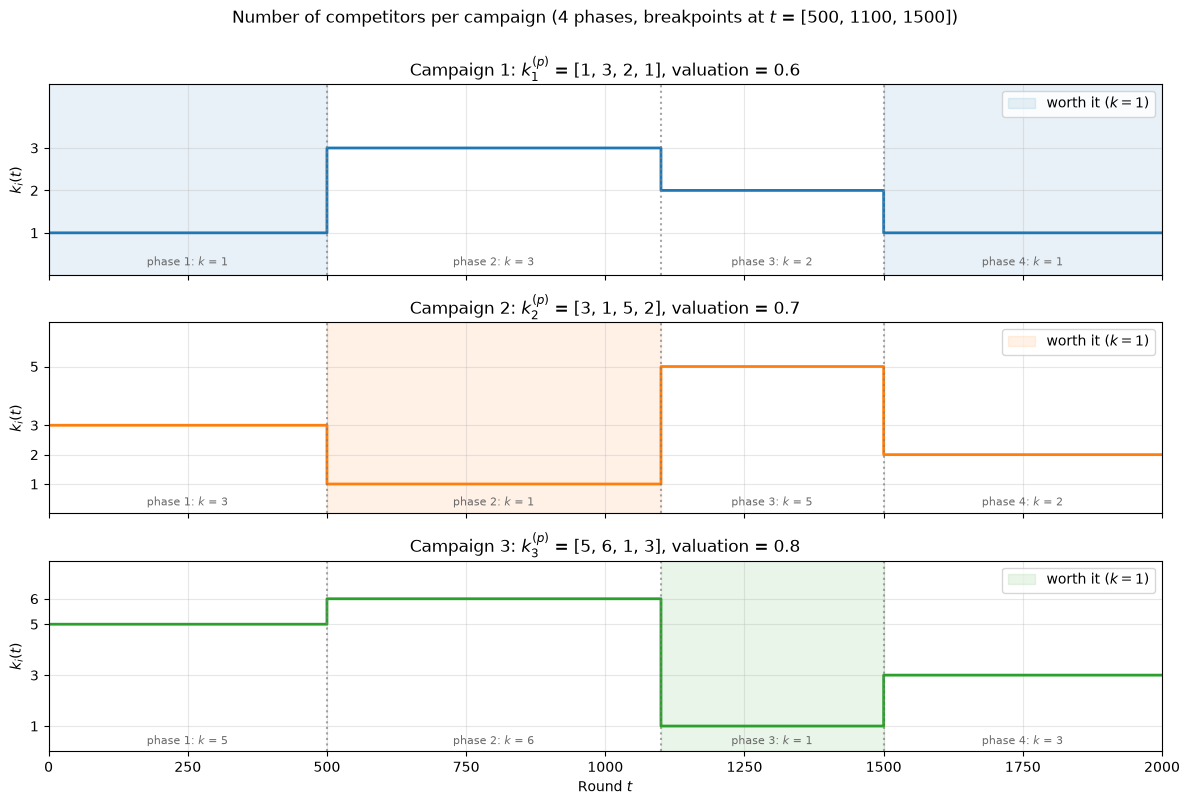

In [55]:
# ------------------------------------------------------------------
# Plot 1: k_i(t) per campaign (one subplot each) to show the phases
# ------------------------------------------------------------------
fig, axes = plt.subplots(n_campaigns, 1, figsize=(12, 8), sharex=True)

for campaign in range(n_campaigns):
    ax = axes[campaign]
    ax.step(
        t, n_competitors_t[campaign],
        where="post", color=f"C{campaign}", linewidth=2
    )

    # vertical lines at the breakpoints (shared by all campaigns)
    for tau in breakpoints[1:-1]:
        ax.axvline(tau, color="gray", linestyle=":", alpha=0.7)

    # shade the phases in which this campaign is the "worth it" one (k = 1)
    first = True
    for p in range(n_phases):
        if k_phases[campaign][p] == 1:
            ax.axvspan(
                breakpoints[p], breakpoints[p + 1],
                color=f"C{campaign}", alpha=0.10,
                label="worth it ($k = 1$)" if first else None
            )
            first = False

    # phase number and k written at the bottom of each phase
    for p in range(n_phases):
        ax.text(
            (breakpoints[p] + breakpoints[p + 1]) / 2, 0.15,
            f"phase {p + 1}: $k$ = {k_phases[campaign][p]}",
            ha="center", va="bottom", fontsize=8, color="dimgray"
        )

    ax.set_ylim(0, max(k_phases[campaign]) + 1.5)
    ax.set_yticks(sorted(set(k_phases[campaign])))
    ax.set_ylabel("$k_i(t)$")
    ax.set_title(
        f"Campaign {campaign + 1}: $k_{campaign + 1}^{{(p)}}$ = {k_phases[campaign]}, "
        f"valuation = {my_valuations[campaign]}"
    )
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Round $t$")
axes[-1].set_xlim(0, n_users)
plt.suptitle(
    f"Number of competitors per campaign ({n_phases} phases, "
    f"breakpoints at $t$ = {breakpoints[1:-1]})", y=1.0
)
plt.tight_layout()
plt.show()

## Benchmark: best policy in hindsight

Inside phase $p$ the environment is stationary with win probabilities $\mathbb{P}^{(p)}_i(b) = b^{\,k_i^{(p)}}$. The clairvoyant that knows the distribution of every phase solves the LP of Requirement 2 (over super-arms $(S, b_S) \in \mathcal{A}$, expected cost per round $\le \rho$) **once per phase**:

$$
\text{OPT}^{(p)} = \max_{\gamma \in \Delta(\mathcal{A})} \sum_{(S,b_S)} \gamma(S,b_S) \sum_{i \in S} (v_i - b_i)\, b_i^{\,k_i^{(p)}}
\quad \text{s.t.} \quad \sum_{(S,b_S)} \gamma(S,b_S) \sum_{i \in S} b_i\, b_i^{\,k_i^{(p)}} \le \rho .
$$

The benchmark is the sum of the phase optima, $\text{OPT} = \sum_p (\tau_p - \tau_{p-1})\, \text{OPT}^{(p)}$, and the **policy regret** is

$$
R_T = \sum_{t=1}^{T} \Big( \text{OPT}^{(p(t))} - \sum_{i \in S_t} (v_i - b_i(t))\, \mathbb{1}\{b_i(t) \ge m_i(t)\} \Big), \qquad p(t) = \text{phase containing } t .
$$

As in Lab 10, this is at least as large as the best *fixed* strategy in hindsight (the Requirement 3 benchmark, computed below for comparison): the gap between the two is the value of being able to track the phases.

In [56]:
## Benchmark: LP of Requirement 2, solved once per phase

from itertools import combinations, product
from collections import namedtuple
from scipy import optimize

ClairvoyantResult = namedtuple(
    "ClairvoyantResult",
    ["gamma", "super_arms", "super_arm_rewards", "super_arm_costs",
     "expected_reward", "expected_cost"]
)


def enumerate_independent_sets(n_campaigns, conflict_edges):
    """All subsets of {0, ..., n_campaigns-1} with no conflicting pair."""
    conflicts = set(conflict_edges)

    def is_independent(subset):
        subset = set(subset)
        return not any({i, j} <= subset for i, j in conflicts)

    return [
        subset
        for size in range(n_campaigns + 1)
        for subset in combinations(range(n_campaigns), size)
        if is_independent(subset)
    ]


def build_super_arms(independent_sets, available_bids, my_valuations):
    """One super-arm per (feasible subset, bid combination), bids <= valuation."""
    super_arms = []
    for subset in independent_sets:
        if not subset:
            super_arms.append((subset, ()))
        else:
            valid_bids_per_campaign = [
                [b for b in available_bids if b <= my_valuations[campaign] + 1e-6]
                for campaign in subset
            ]
            super_arms.extend(
                (subset, bids) for bids in product(*valid_bids_per_campaign)
            )
    return super_arms


def evaluate_super_arms(super_arms, my_valuations, win_probabilities, bid_to_index):
    """Expected reward/cost per round of every super-arm."""
    rewards = np.zeros(len(super_arms))
    costs = np.zeros(len(super_arms))
    for k, (subset, bids) in enumerate(super_arms):
        for campaign, bid in zip(subset, bids):
            p = win_probabilities[campaign, bid_to_index[bid]]
            rewards[k] += (my_valuations[campaign] - bid) * p
            costs[k] += bid * p
    return rewards, costs


def compute_clairvoyant_with_restrictions(
    available_bids, my_valuations, rho, win_probabilities, conflict_edges
):
    """LP: best distribution over super-arms with expected cost per round <= rho."""
    bid_to_index = {b: i for i, b in enumerate(available_bids)}

    independent_sets = enumerate_independent_sets(len(my_valuations), conflict_edges)
    super_arms = build_super_arms(independent_sets, available_bids, my_valuations)
    super_arm_rewards, super_arm_costs = evaluate_super_arms(
        super_arms, my_valuations, win_probabilities, bid_to_index
    )

    result = optimize.linprog(
        -super_arm_rewards,
        A_ub=[super_arm_costs], b_ub=[rho],
        A_eq=[np.ones(len(super_arms))], b_eq=[1],
        bounds=(0, 1), method="highs"
    )
    if not result.success:
        raise ValueError(result.message)

    gamma = result.x
    return ClairvoyantResult(
        gamma, super_arms, super_arm_rewards, super_arm_costs,
        expected_reward=-result.fun,
        expected_cost=gamma @ super_arm_costs,
    )


def print_clairvoyant_solution(result, rho, n_rounds, title):
    print(f"===== {title} =====")
    for (subset, bids), probability, reward, cost in zip(
        result.super_arms, result.gamma, result.super_arm_rewards, result.super_arm_costs
    ):
        if probability > 1e-6:
            print(f"  prob {probability:.4f} | campaigns {[c + 1 for c in subset]} "
                  f"| bids {tuple(round(b, 1) for b in bids)} "
                  f"| reward {reward:.4f} | cost {cost:.4f}")
    print(f"  Expected reward per round: {result.expected_reward:.4f}")
    print(f"  Expected cost per round:   {result.expected_cost:.4f}  (rho = {rho})")
    print(f"  Cumulative OPT over {n_rounds} rounds: {result.expected_reward * n_rounds:.2f}\n")


# --- Best policy in hindsight: one LP per phase, with that phase's distribution b^k ---
win_prob_phase = np.array([
    [available_bids ** k_phases[campaign][p] for campaign in range(n_campaigns)]
    for p in range(n_phases)
])                                                    # shape (n_phases, n_campaigns, n_bids)

clairvoyant_phase = [
    compute_clairvoyant_with_restrictions(
        available_bids, my_valuations, rho, win_prob_phase[p], conflict_edges
    )
    for p in range(n_phases)
]
for p in range(n_phases):
    print_clairvoyant_solution(
        clairvoyant_phase[p], rho, phase_lengths[p],
        f"Phase {p + 1}: rounds [{breakpoints[p]}, {breakpoints[p + 1]}), "
        f"k = {[k_phases[c][p] for c in range(n_campaigns)]}"
    )

# per-round optimum of the best policy (piecewise constant) and its cumulative value
opt_per_round_phase = np.array([c.expected_reward for c in clairvoyant_phase])
opt_t = np.zeros(n_users)
for p in range(n_phases):
    opt_t[breakpoints[p]:breakpoints[p + 1]] = opt_per_round_phase[p]
OPT_policy = opt_t.sum()

# --- Best FIXED strategy in hindsight (Requirement 3 benchmark), for comparison ---
# a fixed strategy faces the time-average of the win probabilities
win_prob_avg = np.tensordot(phase_lengths / n_users, win_prob_phase, axes=1)
clairvoyant_fixed = compute_clairvoyant_with_restrictions(
    available_bids, my_valuations, rho, win_prob_avg, conflict_edges
)
OPT_fixed = clairvoyant_fixed.expected_reward * n_users
print_clairvoyant_solution(clairvoyant_fixed, rho, n_users, "Best FIXED strategy in hindsight")

# Sanity check: theoretical b^k vs empirical win frequency on the realised phase
max_abs_gap = max(
    np.abs(win_prob_phase[p][campaign]
           - np.array([np.mean(b >= m_t_slow[campaign, breakpoints[p]:breakpoints[p + 1]])
                       for b in available_bids])).max()
    for p in range(n_phases) for campaign in range(n_campaigns)
)
print(f"Max |theoretical - empirical| win probability over phases/campaigns/bids: {max_abs_gap:.3f}")

print(f"\nBest POLICY in hindsight: OPT = {OPT_policy:.2f}  "
      f"(per-phase OPT/round = {np.round(opt_per_round_phase, 4)})")
print(f"Best FIXED strategy:      OPT = {OPT_fixed:.2f}")
print(f"Value of tracking the phases: {OPT_policy - OPT_fixed:.2f}")

# Objects used later by the agents
super_arms = clairvoyant_phase[0].super_arms      # same list in every phase (depends only on bids and graph)
print("Number of super-arms:", len(super_arms))

===== Phase 1: rounds [0, 500), k = [1, 3, 5] =====
  prob 0.0678 | campaigns [1, 2] | bids (np.float64(0.3), np.float64(0.4)) | reward 0.1092 | cost 0.1156
  prob 0.9322 | campaigns [1, 2] | bids (np.float64(0.3), np.float64(0.5)) | reward 0.1150 | cost 0.1525
  Expected reward per round: 0.1146
  Expected cost per round:   0.1500  (rho = 0.15)
  Cumulative OPT over 500 rounds: 57.30

===== Phase 2: rounds [500, 1100), k = [3, 1, 6] =====
  prob 1.0000 | campaigns [1, 2] | bids (np.float64(0.4), np.float64(0.3)) | reward 0.1328 | cost 0.1156
  Expected reward per round: 0.1328
  Expected cost per round:   0.1156  (rho = 0.15)
  Cumulative OPT over 600 rounds: 79.68

===== Phase 3: rounds [1100, 1500), k = [2, 5, 1] =====
  prob 0.5286 | campaigns [1, 3] | bids (np.float64(0.3), np.float64(0.3)) | reward 0.1770 | cost 0.1170
  prob 0.4714 | campaigns [1, 3] | bids (np.float64(0.3), np.float64(0.4)) | reward 0.1870 | cost 0.1870
  Expected reward per round: 0.1817
  Expected cost per ro

## Combinatorial-UCB with Sliding Window

In Requirement 2 the Combinatorial-UCB agent keeps, for every base arm $(i, b)$ (campaign $i$, bid $b$), the average reward, the average cost and the number of pulls over **all** past rounds. It then plays the LP over super-arms $(S, b_S) \in \mathcal{A}$ using an optimistic reward and a pessimistic cost for each base arm.

**Why this is not enough here.** After a breakpoint the arm that was good in the previous phase keeps a high average, its confidence radius is already small, and the agent never questions it again; the arm that has just become good is never re-tried. This is the same convex-shaped regret of UCB1 in Lab 10.

**The fix: forget old samples (SW-UCB, Lab 10).** Keep only the observations of the last $W$ rounds. For every base arm $(i, b)$ let $n^W_{i,b}$ be the number of observations in the window and $\hat{\mathbb{P}}^W_i(b)$ its empirical win probability in the window. The estimates are

$$
\mathbb{P}^{\text{UCB}}_i(b) = \hat{\mathbb{P}}^W_i(b) + c\sqrt{\frac{2 \log W}{n^W_{i,b}}}, \qquad
\mathbb{P}^{\text{LCB}}_i(b) = \hat{\mathbb{P}}^W_i(b) - c\sqrt{\frac{2 \log W}{n^W_{i,b}}},
$$

clipped to $[0, 1]$ ($\log W$ instead of $\log T$, as in the lab). With full feedback the win indicator $\mathbb{1}\{b \ge m_i(t)\}$ of every base arm is observed every round (as for the primal-dual agent of Requirement 3), so all base arms have $n^W_{i,b} = \min(t, W)$ samples in the window and the same confidence radius. Since reward and cost are both driven by the win indicator,

$$
f^{\text{UCB}}_i(b) = (v_i - b)\, \mathbb{P}^{\text{UCB}}_i(b), \qquad c^{\text{LCB}}_i(b) = b\, \mathbb{P}^{\text{LCB}}_i(b),
$$

and, because $\mathbb{P}_i(b) = \mathbb{P}(b \geq m_i)$ is non-decreasing in $b$, we tighten the bounds so that a bid is never more optimistic than a higher bid nor less pessimistic than a lower one.

The rest is the Requirement 2 agent: sum the estimates over the base arms of each super-arm, solve

$$
\text{maximize}_{\gamma \in \Delta(\mathcal{A})} \; \sum_{(S,b_S)} \gamma(S,b_S) \sum_{i \in S} f^{\text{UCB}}_i(b_i)
\qquad \text{s.t.} \; \sum_{(S,b_S)} \gamma(S,b_S) \sum_{i \in S} c^{\text{LCB}}_i(b_i) \leq \rho,
$$

sample the super-arm from $\gamma$, and stop bidding when the budget is exhausted. Since every base arm is observed every round, the exploration bonus is less important than in the bandit setting and mostly inflates the low bids, which are cheap but rarely win; we therefore scale the radius by $c = 0.1$ ($c = 0$ is the agent that simply plays the LP on the empirical win probabilities of the window) and check the sensitivity to $c$.

**Choice of $W$.** Lab 10 suggests $W = \lfloor 2\sqrt{T \log T / \Upsilon_T} \rfloor$ when the number of changes $\Upsilon_T$ is known (here $\Upsilon_T = 3$, so $W \approx 142$) or $W \approx 2\sqrt{T}$ in practice. A small $W$ gives noisy estimates inside a phase, a large $W$ drags samples across a breakpoint; the phases have different lengths on purpose, so we also check the sensitivity to $W$.

In [57]:
## Combinatorial-UCB with Sliding Window (full feedback)

class SWCombinatorialUCBAgent:
    def __init__(self, n_campaigns, available_bids, my_valuations, B, T, super_arms, W, c=0.1):
        self.n_campaigns = n_campaigns
        self.available_bids = np.asarray(available_bids)
        self.n_bids = len(available_bids)
        self.my_valuations = np.asarray(my_valuations)
        self.T = T
        self.W = W                      # window length (rounds)
        self.c = c                      # scale of the confidence radius c * sqrt(2 log W / n)
        self.budget = B
        self.rho = B / T
        self.t = 0

        # sliding-window cache of the win indicator 1{b >= m_i(t)} of every base arm (campaign, bid):
        # one row per round, NaN = round not observed yet. Only the last W rounds are kept.
        self.cache_wins = np.full((W, n_campaigns, self.n_bids), np.nan)

        # feasible super-arms precomputed by compute_clairvoyant_with_restrictions
        self.super_arms = super_arms
        self.bid_to_index = {round(bid, 8): idx for idx, bid in enumerate(available_bids)}
        self.opt_out_idx = next(k for k, (subset, _) in enumerate(super_arms) if len(subset) == 0)

        # incidence matrix super-arm x base-arm: reward/cost of a super-arm = sum over its base arms
        self.incidence = np.zeros((len(super_arms), n_campaigns * self.n_bids))
        for k, (campaign_subset, bids) in enumerate(super_arms):
            for campaign, bid in zip(campaign_subset, bids):
                self.incidence[k, campaign * self.n_bids + self.bid_to_index[round(bid, 8)]] = 1.0

        # log
        self.N_pulls = np.zeros(len(super_arms))
        self.S_t, self.bids_t, self.super_arm_idx_t = (), (), self.opt_out_idx

    def _window_estimates(self):
        # number of observations and empirical win probability of every base arm in the last W rounds
        # (full feedback: every base arm is observed every round, so n_w = min(t, W) for all of them)
        n_w = self.W - np.isnan(self.cache_wins).sum(axis=0)
        with np.errstate(invalid="ignore"):                 # nanmean of an all-NaN column -> NaN
            p_hat = np.nanmean(self.cache_wins, axis=0)
        unexplored = n_w == 0                               # only at t = 0

        radius = np.zeros((self.n_campaigns, self.n_bids))
        radius[~unexplored] = self.c * np.sqrt(2 * np.log(self.W) / n_w[~unexplored])

        p_ucb = np.clip(p_hat + radius, 0.0, 1.0)
        p_lcb = np.clip(p_hat - radius, 0.0, 1.0)
        p_ucb[unexplored] = 1.0                             # optimistic placeholder
        p_lcb[unexplored] = 0.0

        # P_i(b) is non-decreasing in b: a bid is never more optimistic than a higher bid
        # (running min from the right) nor less pessimistic than a lower bid (running max from the left)
        p_ucb = np.minimum.accumulate(p_ucb[:, ::-1], axis=1)[:, ::-1]
        p_lcb = np.maximum.accumulate(p_lcb, axis=1)

        f_ucb = (self.my_valuations[:, None] - self.available_bids[None, :]) * p_ucb
        c_lcb = self.available_bids[None, :] * p_lcb
        return f_ucb, c_lcb

    def pull_arm(self):
        # budget exhausted: opt-out of every campaign this round
        if self.budget < 1:
            self.super_arm_idx_t = self.opt_out_idx
            self.S_t, self.bids_t = self.super_arms[self.super_arm_idx_t]
            return self.S_t, self.bids_t

        f_ucb, c_lcb = self._window_estimates()

        # reward/cost of every feasible super-arm under current estimates
        super_arm_f_ucb = self.incidence @ f_ucb.ravel()
        super_arm_c_lcb = self.incidence @ c_lcb.ravel()

        gamma_t = self._compute_opt(super_arm_f_ucb, super_arm_c_lcb)

        self.super_arm_idx_t = np.random.choice(len(self.super_arms), p=gamma_t)
        self.S_t, self.bids_t = self.super_arms[self.super_arm_idx_t]
        return self.S_t, self.bids_t

    def _compute_opt(self, super_arm_f_ucb, super_arm_c_lcb):
        # Exact solution of the LP  max gamma.f  s.t. gamma.c <= rho, gamma in the simplex.
        # With a single budget constraint the optimum mixes at most two super-arms: the endpoints of
        # the edge of the upper convex hull of the points (c_k, f_k) that crosses c = rho (fractional
        # knapsack). Same solution as optimize.linprog, ~10x faster (it is called every round).
        f, c, rho = super_arm_f_ucb, super_arm_c_lcb, self.rho
        gamma = np.zeros(len(f))
        best = np.argmax(f)
        if c[best] <= rho:                          # the best super-arm is affordable: play it
            gamma[best] = 1.0
            return gamma
        order = np.lexsort((-f, c))                 # by increasing cost, ties by decreasing reward
        hull = []                                   # upper convex hull (monotone chain)
        for k in order:
            while len(hull) >= 2:
                i, j = hull[-2], hull[-1]
                if (c[j] - c[i]) * (f[k] - f[i]) >= (f[j] - f[i]) * (c[k] - c[i]):
                    hull.pop()                      # j is on or below the segment i -> k
                else:
                    break
            hull.append(k)
        hull = np.array(hull)
        hull = hull[:np.argmax(f[hull]) + 1]        # keep the increasing part only
        pos = np.searchsorted(c[hull], rho, side="right")
        i, j = hull[pos - 1], hull[pos]             # c_i <= rho < c_j
        w = (rho - c[i]) / (c[j] - c[i])            # mix so that the expected cost is exactly rho
        gamma[i], gamma[j] = 1 - w, w
        return gamma

    def update(self, c_t, m_t):
        # full feedback: m_t is the vector of highest competing bids of this round, so the win
        # indicator 1{b >= m_i(t)} of EVERY base arm is observed (as the primal-dual agent of Req. 3)
        row = self.t % self.W                  # overwrite the oldest round of the window
        self.cache_wins[row] = (self.available_bids[None, :] >= m_t[:, None]).astype(float)
        self.budget -= sum(c_t)                # c_t: realized cost of each campaign in S_t
        self.N_pulls[self.super_arm_idx_t] += 1
        self.t += 1

In [58]:
## Multi-Trial Simulation: SW-CUCB on the slightly non-stationary environment

T = n_users
n_trials = 10

U_T = n_phases - 1                                  # number of abrupt changes
W = int(2 * np.sqrt(T * np.log(T) / U_T))           # Lab 10 window, U_T known
print(f"Window W = {W}")

regret_per_trial = []
cost_per_trial = []
super_arm_per_trial = []                            # index of the super-arm played at every round

for trial in range(n_trials):
    np.random.seed(trial)

    agent = SWCombinatorialUCBAgent(
        n_campaigns=n_campaigns,
        available_bids=available_bids,
        my_valuations=my_valuations,
        B=B,
        T=T,
        super_arms=super_arms,
        W=W
    )

    utilities = np.zeros(T)
    costs = np.zeros(T)
    played = np.zeros(T, dtype=int)

    for round_t in range(T):
        S_t, bids_t = agent.pull_arm()
        m_round = m_t_slow[:, round_t]

        f_t = [(my_valuations[i] - b) * (b >= m_round[i]) for i, b in zip(S_t, bids_t)]
        c_t = [b * (b >= m_round[i]) for i, b in zip(S_t, bids_t)]

        agent.update(c_t, m_round)                  # full feedback

        utilities[round_t] = sum(f_t)
        costs[round_t] = sum(c_t)
        played[round_t] = agent.super_arm_idx_t

    # policy regret: per-round optimum of the phase containing t
    regret_per_trial.append(np.cumsum(opt_t - utilities))
    cost_per_trial.append(np.cumsum(costs))
    super_arm_per_trial.append(played)

regret_per_trial = np.array(regret_per_trial)
cost_per_trial = np.array(cost_per_trial)
super_arm_per_trial = np.array(super_arm_per_trial)

avg_regret = regret_per_trial.mean(axis=0)
std_regret = regret_per_trial.std(axis=0)
avg_cost = cost_per_trial.mean(axis=0)
std_cost = cost_per_trial.std(axis=0)

rounds = np.arange(T)

print(f"Final regret: {avg_regret[-1]:.1f} ± {std_regret[-1]:.1f}   "
      f"(OPT policy = {OPT_policy:.1f}, OPT fixed = {OPT_fixed:.1f})")
print(f"Final cost:   {avg_cost[-1]:.1f} / {B}")

Window W = 142


C:\Users\Recup\AppData\Local\Temp\ipykernel_25196\1272385443.py:40: RuntimeWarning: Mean of empty slice
  p_hat = np.nanmean(self.cache_wins, axis=0)


Final regret: 20.3 ± 1.3   (OPT policy = 278.3, OPT fixed = 212.5)
Final cost:   258.5 / 300


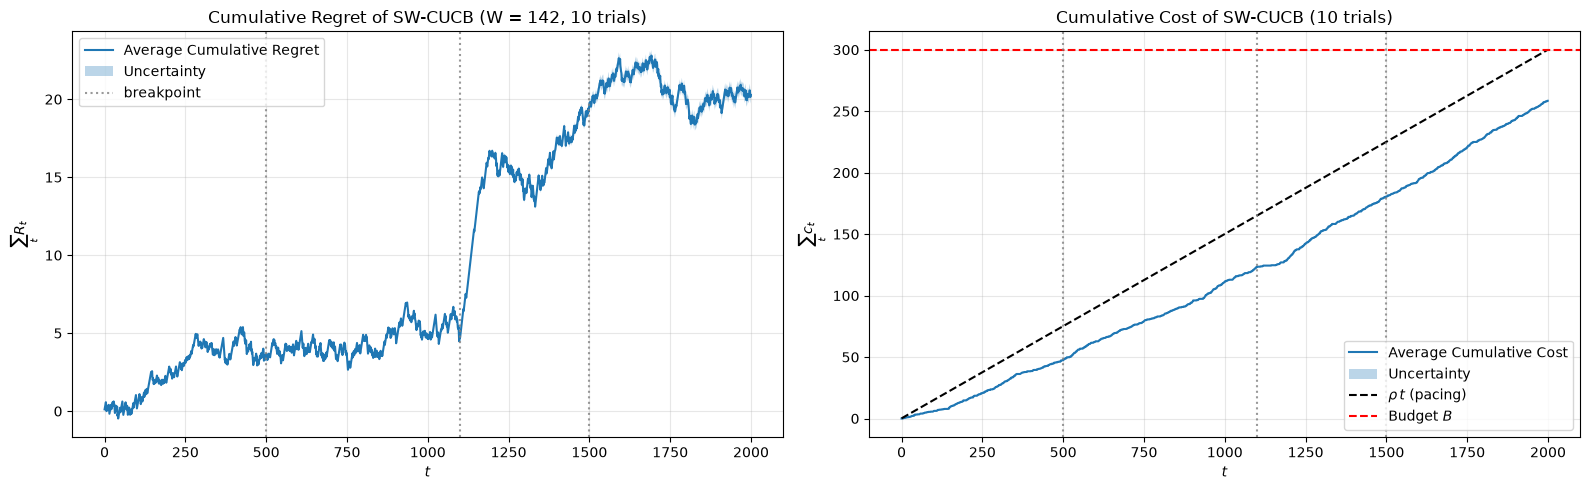

In [59]:
# --- Cumulative regret and cumulative cost of SW-CUCB ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(rounds, avg_regret, label="Average Cumulative Regret")
axes[0].fill_between(rounds,
                     avg_regret - std_regret / np.sqrt(n_trials),
                     avg_regret + std_regret / np.sqrt(n_trials),
                     alpha=0.3, label="Uncertainty")
for tau in breakpoints[1:-1]:
    axes[0].axvline(tau, color="gray", linestyle=":", alpha=0.8,
                    label="breakpoint" if tau == breakpoints[1] else None)
axes[0].set_xlabel("$t$")
axes[0].set_ylabel(r"$\sum_t R_t$")
axes[0].set_title(f"Cumulative Regret of SW-CUCB (W = {W}, {n_trials} trials)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rounds, avg_cost, label="Average Cumulative Cost")
axes[1].fill_between(rounds,
                     avg_cost - std_cost / np.sqrt(n_trials),
                     avg_cost + std_cost / np.sqrt(n_trials),
                     alpha=0.3, label="Uncertainty")
axes[1].plot(rounds, rho * (rounds + 1), "k--", label=r"$\rho\, t$ (pacing)")
axes[1].axhline(B, color="red", linestyle="--", label="Budget $B$")
for tau in breakpoints[1:-1]:
    axes[1].axvline(tau, color="gray", linestyle=":", alpha=0.8)
axes[1].set_xlabel("$t$")
axes[1].set_ylabel(r"$\sum_t c_t$")
axes[1].set_title(f"Cumulative Cost of SW-CUCB ({n_trials} trials)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

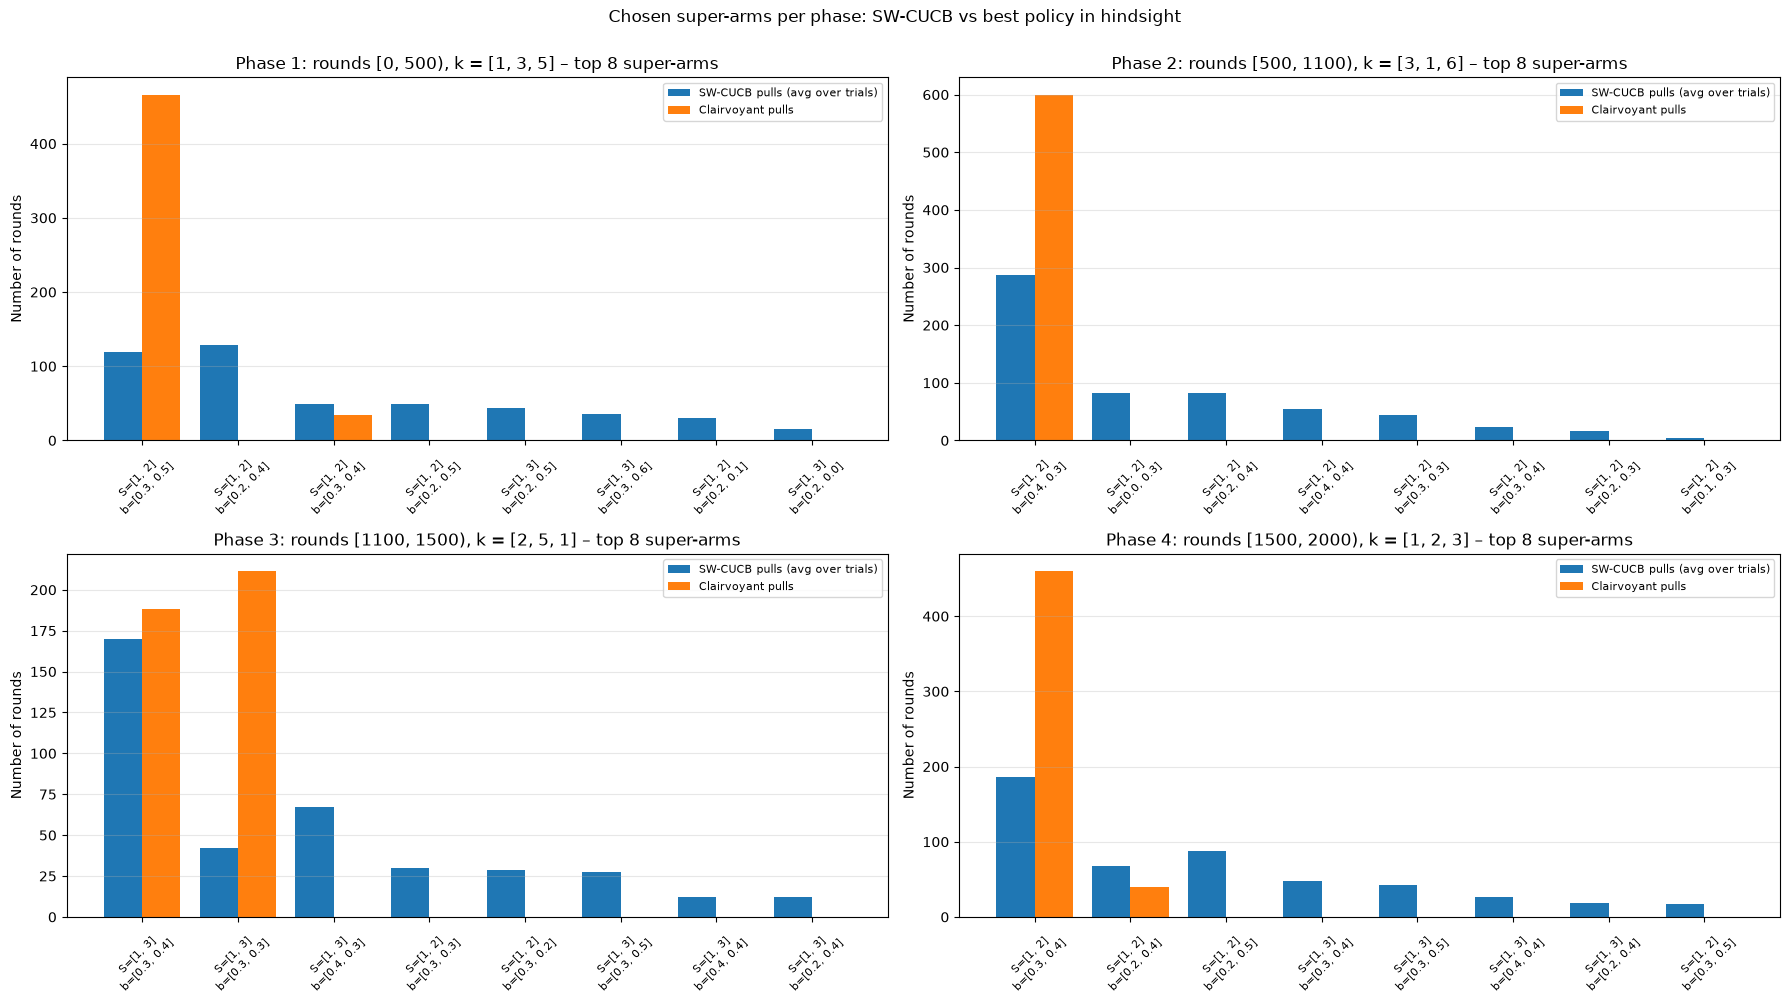

In [60]:
# --- Number of pulls per super-arm, phase by phase, vs the clairvoyant of that phase ---
# (average over trials; the clairvoyant plays gamma_p * phase_length rounds of each super-arm)

def plot_pulls_per_phase(super_arm_per_trial, name, n_top=8):
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.ravel()
    for p in range(n_phases):
        lo, hi = breakpoints[p], breakpoints[p + 1]

        agent_pulls = np.zeros(len(super_arms))
        for trial in range(super_arm_per_trial.shape[0]):
            agent_pulls += np.bincount(super_arm_per_trial[trial, lo:hi], minlength=len(super_arms))
        agent_pulls /= super_arm_per_trial.shape[0]
        clairvoyant_pulls = clairvoyant_phase[p].gamma * (hi - lo)

        top = np.argsort(-(agent_pulls + clairvoyant_pulls))[:n_top]
        labels = [
            f"S={[c + 1 for c in super_arms[k][0]]}\nb={[round(float(b), 1) for b in super_arms[k][1]]}"
            for k in top
        ]
        x = np.arange(len(top))
        width = 0.4
        ax = axes[p]
        ax.bar(x - width / 2, agent_pulls[top], width=width, label=f"{name} pulls (avg over trials)")
        ax.bar(x + width / 2, clairvoyant_pulls[top], width=width, label="Clairvoyant pulls")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=8, rotation=45)
        ax.set_title(f"Phase {p + 1}: rounds [{lo}, {hi}), "
                     f"k = {[k_phases[c][p] for c in range(n_campaigns)]} – top {n_top} super-arms")
        ax.set_ylabel("Number of rounds")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3, axis="y")
    plt.suptitle(f"Chosen super-arms per phase: {name} vs best policy in hindsight", y=1.0)
    plt.tight_layout()
    plt.show()


plot_pulls_per_phase(super_arm_per_trial, "SW-CUCB")

**Results of SW-CUCB.** With $W = 142$ the final regret w.r.t. the best policy in hindsight is $\approx 20$ (OPT $= 278.3$), i.e. the agent collects about $93\%$ of the clairvoyant reward, while spending $258$ of the $300$ budget; the best *fixed* strategy would be $66$ behind the same benchmark, so the window is clearly tracking the phases.

The regret curve has the staircase shape of Lab 10: it is almost flat inside each phase and grows only in the rounds after a breakpoint, most visibly at $t = 1100$ where the profitable campaign switches from 2 to 3 and the agent needs roughly one window to forget the phase-2 samples. The cost stays close to the pacing line $\rho\,t$: with the same estimate $\hat{\mathbb{P}}$ for reward and cost the LP spends the budget where it is worth it.

The pulls per phase confirm the picture: in every phase most of the mass is on the clairvoyant super-arm ($S = \{1,2\}$ with $b = (0.3, 0.5)$, then $(0.4, 0.3)$, then $S = \{1,3\}$ with $b = (0.3, 0.4)$, then $S = \{1,2\}$ with $(0.3, 0.4)$), and the residual mass sits on the same campaigns with a bid one step lower, which is the small optimism left on the cheap bids by $c = 0.1$.

## Combinatorial-UCB with Change Detection (CUSUM-CUCB)

**Idea (CUSUM-UCB, Lab 10).** Instead of forgetting continuously, keep the Requirement 2 statistics (all samples since the last reset) and run a **change detector** on every base arm $(i, b)$. When it fires, reset the statistics of that arm only, so it is learned again from scratch while the other arms keep their still-valid estimates.

**What is monitored.** The quantity that jumps at a breakpoint is the win probability $\mathbb{P}_i(b) = b^{\,k_i(t)}$, so the detector of base arm $(i, b)$ runs on the win indicator $X_t = \mathbb{1}\{b \ge m_i(t)\} \sim \text{Bernoulli}(b^{\,k_i(t)})$, observed every round for every base arm thanks to the full feedback.

**CUSUM (Liu et al., 2018).** After a reset, the first $M$ samples fix a reference mean $\hat u_0$. Then two cumulative sums track upward and downward deviations,

$$
g^+_t = \max\{0,\, g^+_{t-1} + (X_t - \hat u_0 - \varepsilon)\}, \qquad
g^-_t = \max\{0,\, g^-_{t-1} + (\hat u_0 - X_t - \varepsilon)\},
$$

and a change is declared when $\max\{g^+_t, g^-_t\} \ge h$. The threshold $h$ trades detection delay against false alarms, $\varepsilon$ is a small tolerance that keeps the sums from drifting when nothing changed, and $M$ controls how reliable $\hat u_0$ is. As in the lab, $h = 2\log(T/\Upsilon_T)$ and $M \in [\log(T/\Upsilon_T), \sqrt{T/\Upsilon_T}]$.

**Estimates and action.** With $n_{i,b}$ samples and empirical win probability $\hat{\mathbb{P}}_i(b)$ since the last reset,

$$
\mathbb{P}^{\text{UCB}}_i(b) = \hat{\mathbb{P}}_i(b) + c\sqrt{\frac{2 \log T}{n_{i,b}}}, \qquad
\mathbb{P}^{\text{LCB}}_i(b) = \hat{\mathbb{P}}_i(b) - c\sqrt{\frac{2 \log T}{n_{i,b}}},
$$

followed by the same monotone tightening, the same $f^{\text{UCB}}_i(b) = (v_i - b)\,\mathbb{P}^{\text{UCB}}_i(b)$, $c^{\text{LCB}}_i(b) = b\,\mathbb{P}^{\text{LCB}}_i(b)$ and the same LP over super-arms as SW-CUCB. A reset arm has $n_{i,b} = 0$ and is treated optimistically, so it is re-estimated quickly. Since resets are per base arm, right after a breakpoint some bids of a campaign may have been reset while others have not: the monotone tightening keeps the freshly reset (very optimistic) bids consistent with their neighbours. The extra uniform exploration $\alpha$ of the lab is not needed, because with full feedback every base arm is observed every round whether or not it is played.

**Sliding window vs change detection.** SW-CUCB pays a constant price for forgetting (only $W$ samples are ever used) but needs no detection; CUSUM-CUCB uses all the samples of the current phase, hence sharper estimates inside a phase, but pays a detection delay after every breakpoint and can be fooled by false alarms. The lab notes the same trade-off: comparable performance, more hyper-parameters and more assumptions for CUSUM.

In [61]:
## Combinatorial-UCB with CUSUM change detection (full feedback)

class CUSUMCombinatorialUCBAgent(SWCombinatorialUCBAgent):
    def __init__(self, n_campaigns, available_bids, my_valuations, B, T, super_arms,
                 M, h, eps=0.05, c=0.1):
        # same super-arms, incidence matrix, budget and LP as SW-CUCB; the window cache is not used,
        # the statistics are cumulative since the last reset of each base arm
        super().__init__(n_campaigns, available_bids, my_valuations, B, T, super_arms, W=1, c=c)
        self.M, self.h, self.eps = M, h, eps

        shape = (n_campaigns, self.n_bids)
        self.n_samples = np.zeros(shape)      # samples of the win indicator since the last reset
        self.p_hat = np.zeros(shape)          # empirical win probability since the last reset
        # CUSUM state per base arm
        self.u0_sum = np.zeros(shape)         # sum of the first M samples -> reference mean u0
        self.u0 = np.zeros(shape)
        self.g_plus = np.zeros(shape)
        self.g_minus = np.zeros(shape)
        # log
        self.n_resets = np.zeros(shape)
        self.reset_history = []               # (t, campaign, bid_index)

    def _window_estimates(self):
        # same as SW-CUCB, with the cumulative statistics since the last reset and log T
        unexplored = self.n_samples == 0
        radius = np.zeros_like(self.p_hat)
        radius[~unexplored] = self.c * np.sqrt(2 * np.log(self.T) / self.n_samples[~unexplored])

        p_ucb = np.clip(self.p_hat + radius, 0.0, 1.0)
        p_lcb = np.clip(self.p_hat - radius, 0.0, 1.0)
        p_ucb[unexplored] = 1.0
        p_lcb[unexplored] = 0.0
        p_ucb = np.minimum.accumulate(p_ucb[:, ::-1], axis=1)[:, ::-1]
        p_lcb = np.maximum.accumulate(p_lcb, axis=1)

        f_ucb = (self.my_valuations[:, None] - self.available_bids[None, :]) * p_ucb
        c_lcb = self.available_bids[None, :] * p_lcb
        return f_ucb, c_lcb

    def update(self, c_t, m_t):
        # full feedback: win indicator of every base arm this round
        x = (self.available_bids[None, :] >= m_t[:, None]).astype(float)

        # --- CUSUM change detection, vectorised over all base arms ---
        warming = self.n_samples < self.M                        # still building the reference mean
        self.u0_sum[warming] += x[warming]
        last_warmup = warming & (self.n_samples == self.M - 1)   # M-th sample: fix u0
        self.u0[last_warmup] = self.u0_sum[last_warmup] / self.M

        monitoring = ~warming
        self.g_plus[monitoring] = np.maximum(
            0.0, self.g_plus[monitoring] + (x[monitoring] - self.u0[monitoring] - self.eps))
        self.g_minus[monitoring] = np.maximum(
            0.0, self.g_minus[monitoring] + (self.u0[monitoring] - x[monitoring] - self.eps))
        fired = monitoring & (np.maximum(self.g_plus, self.g_minus) >= self.h)

        # --- update the statistics of the arms that did not fire ...
        keep = ~fired
        self.n_samples[keep] += 1
        self.p_hat[keep] += (x[keep] - self.p_hat[keep]) / self.n_samples[keep]

        # --- ... and reset the arms that fired
        if fired.any():
            for campaign, j in zip(*np.nonzero(fired)):
                self.n_resets[campaign, j] += 1
                self.reset_history.append((self.t, campaign, j))
            for arr in (self.n_samples, self.p_hat, self.u0_sum, self.u0, self.g_plus, self.g_minus):
                arr[fired] = 0.0

        self.budget -= sum(c_t)
        self.N_pulls[self.super_arm_idx_t] += 1
        self.t += 1

In [62]:
## Multi-Trial Simulation: CUSUM-CUCB on the slightly non-stationary environment

h = 2 * np.log(T / U_T)                              # detection threshold (Lab 10)
M = int(np.sqrt(T / U_T) / 2)                        # warm-up samples, in [log(T/U_T), sqrt(T/U_T)]
eps = 0.05                                           # CUSUM tolerance
print(f"h = {h:.2f}, M = {M}, eps = {eps}")

regret_per_trial_cusum = []
cost_per_trial_cusum = []
super_arm_per_trial_cusum = []
resets_per_trial_cusum = []                          # list of (t, campaign, bid_index) per trial

for trial in range(n_trials):
    np.random.seed(trial)

    agent = CUSUMCombinatorialUCBAgent(
        n_campaigns=n_campaigns,
        available_bids=available_bids,
        my_valuations=my_valuations,
        B=B,
        T=T,
        super_arms=super_arms,
        M=M, h=h, eps=eps
    )

    utilities = np.zeros(T)
    costs = np.zeros(T)
    played = np.zeros(T, dtype=int)

    for round_t in range(T):
        S_t, bids_t = agent.pull_arm()
        m_round = m_t_slow[:, round_t]

        f_t = [(my_valuations[i] - b) * (b >= m_round[i]) for i, b in zip(S_t, bids_t)]
        c_t = [b * (b >= m_round[i]) for i, b in zip(S_t, bids_t)]

        agent.update(c_t, m_round)                   # full feedback

        utilities[round_t] = sum(f_t)
        costs[round_t] = sum(c_t)
        played[round_t] = agent.super_arm_idx_t

    regret_per_trial_cusum.append(np.cumsum(opt_t - utilities))
    cost_per_trial_cusum.append(np.cumsum(costs))
    super_arm_per_trial_cusum.append(played)
    resets_per_trial_cusum.append(agent.reset_history)

regret_per_trial_cusum = np.array(regret_per_trial_cusum)
cost_per_trial_cusum = np.array(cost_per_trial_cusum)
super_arm_per_trial_cusum = np.array(super_arm_per_trial_cusum)

avg_regret_cusum = regret_per_trial_cusum.mean(axis=0)
std_regret_cusum = regret_per_trial_cusum.std(axis=0)
avg_cost_cusum = cost_per_trial_cusum.mean(axis=0)
std_cost_cusum = cost_per_trial_cusum.std(axis=0)

print(f"Final regret: {avg_regret_cusum[-1]:.1f} ± {std_regret_cusum[-1]:.1f}   "
      f"(SW-CUCB: {avg_regret[-1]:.1f}, OPT policy = {OPT_policy:.1f}, OPT fixed = {OPT_fixed:.1f})")
print(f"Final cost:   {avg_cost_cusum[-1]:.1f} / {B}")
print(f"Resets per trial: {np.mean([len(r) for r in resets_per_trial_cusum]):.1f} "
      f"(over {n_campaigns * len(available_bids)} base arms and {U_T} breakpoints)")

h = 13.00, M = 12, eps = 0.05
Final regret: 27.3 ± 1.1   (SW-CUCB: 20.3, OPT policy = 278.3, OPT fixed = 212.5)
Final cost:   247.5 / 300
Resets per trial: 133.0 (over 33 base arms and 3 breakpoints)


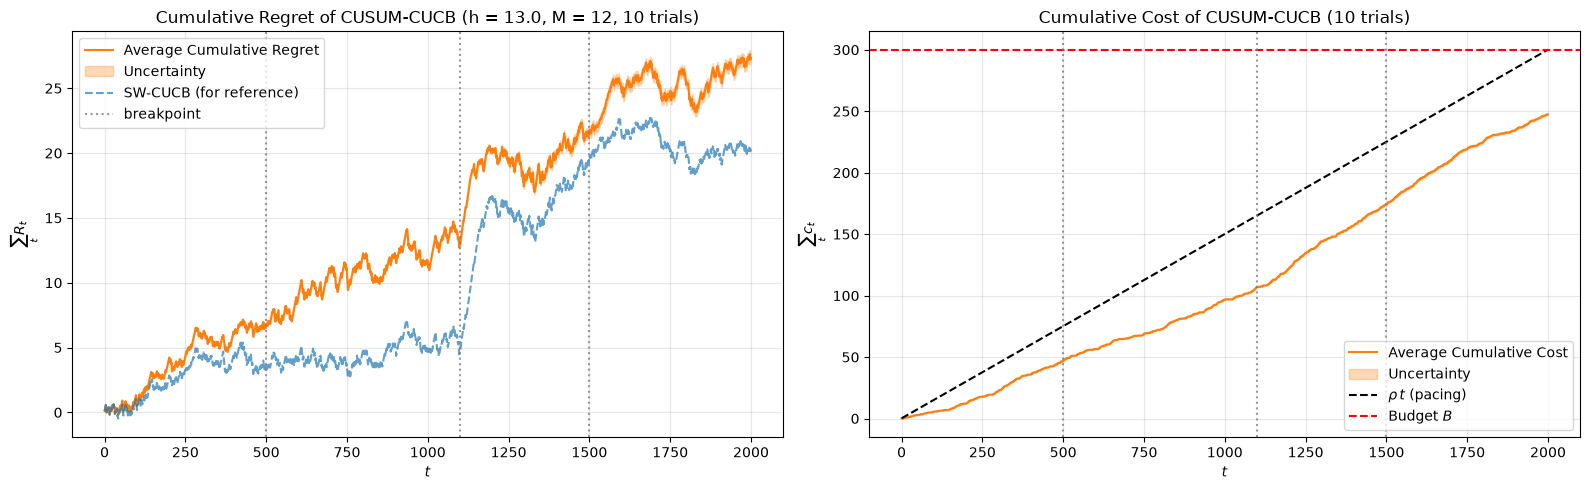

In [63]:
# --- Cumulative regret and cumulative cost of CUSUM-CUCB ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(rounds, avg_regret_cusum, color="C1", label="Average Cumulative Regret")
axes[0].fill_between(rounds,
                     avg_regret_cusum - std_regret_cusum / np.sqrt(n_trials),
                     avg_regret_cusum + std_regret_cusum / np.sqrt(n_trials),
                     color="C1", alpha=0.3, label="Uncertainty")
axes[0].plot(rounds, avg_regret, color="C0", linestyle="--", alpha=0.7, label="SW-CUCB (for reference)")
for tau in breakpoints[1:-1]:
    axes[0].axvline(tau, color="gray", linestyle=":", alpha=0.8,
                    label="breakpoint" if tau == breakpoints[1] else None)
axes[0].set_xlabel("$t$")
axes[0].set_ylabel(r"$\sum_t R_t$")
axes[0].set_title(f"Cumulative Regret of CUSUM-CUCB (h = {h:.1f}, M = {M}, {n_trials} trials)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rounds, avg_cost_cusum, color="C1", label="Average Cumulative Cost")
axes[1].fill_between(rounds,
                     avg_cost_cusum - std_cost_cusum / np.sqrt(n_trials),
                     avg_cost_cusum + std_cost_cusum / np.sqrt(n_trials),
                     color="C1", alpha=0.3, label="Uncertainty")
axes[1].plot(rounds, rho * (rounds + 1), "k--", label=r"$\rho\, t$ (pacing)")
axes[1].axhline(B, color="red", linestyle="--", label="Budget $B$")
for tau in breakpoints[1:-1]:
    axes[1].axvline(tau, color="gray", linestyle=":", alpha=0.8)
axes[1].set_xlabel("$t$")
axes[1].set_ylabel(r"$\sum_t c_t$")
axes[1].set_title(f"Cumulative Cost of CUSUM-CUCB ({n_trials} trials)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

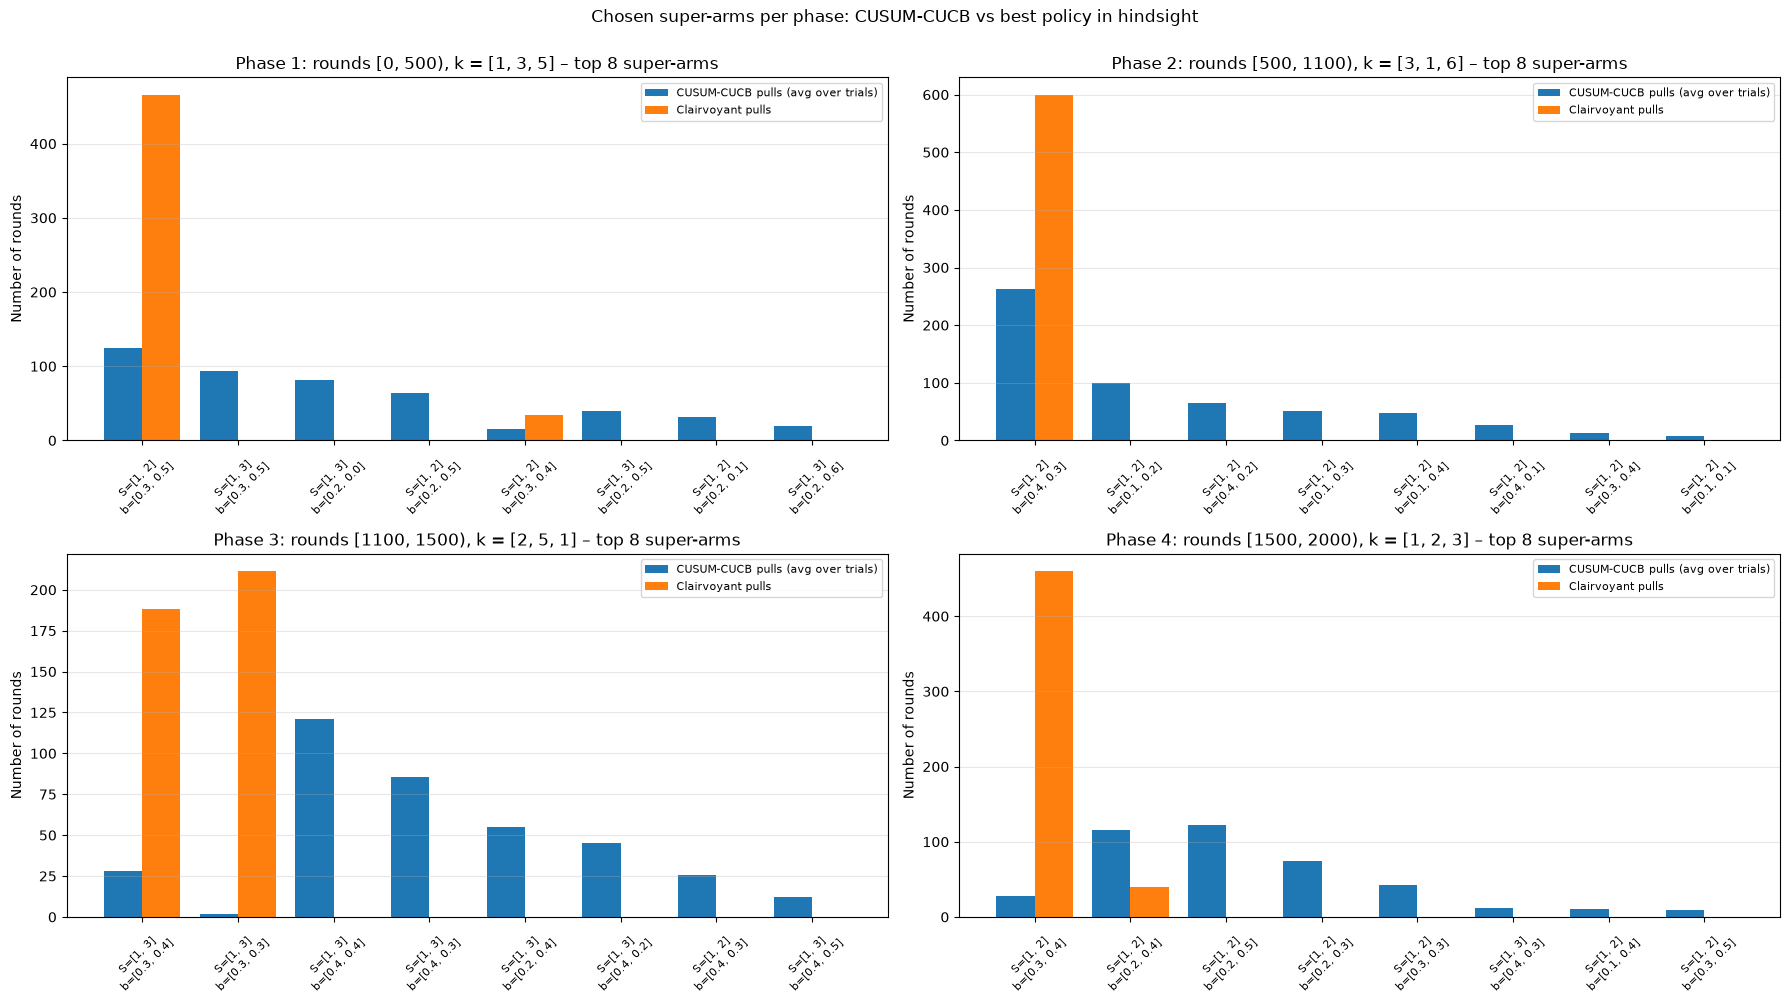

In [68]:
plot_pulls_per_phase(super_arm_per_trial_cusum, "CUSUM-CUCB")

## Primal-dual method of Requirement 3

**The agent.** Exactly the full-feedback primal-dual agent of Requirement 3: Hedge over the super-arms $(S, b_S) \in \mathcal{A}$ on the Lagrangian

$$
\mathcal{L}_t(a) = f_t(a) - \lambda_t \big( c_t(a) - \rho \big), \qquad
f_t(S, b_S) = \sum_{i \in S} (v_i - b_i)\,\mathbb{1}\{b_i \ge m_i(t)\}, \quad
c_t(S, b_S) = \sum_{i \in S} b_i\,\mathbb{1}\{b_i \ge m_i(t)\},
$$

where the primal player updates the weights of *every* super-arm from the observed $m(t)$ (full feedback) and the dual player runs online gradient descent on the multiplier, $\lambda_{t+1} = \Pi_{[0, 1/\rho]}\big(\lambda_t - \eta\,(\rho - c_t)\big)$, so that spending above the pacing rate $\rho$ makes every costly super-arm less attractive. Same hyper-parameters as in Requirement 3 ($\eta = 0.05$, $\eta_{\text{hedge}} = 20$); nothing is tuned for the non-stationarity.

**What to expect.** Its guarantee is adversarial: no regret w.r.t. the best *fixed* strategy in hindsight, whatever the sequence $m(1), \dots, m(T)$. That was the right guarantee in Requirement 3, where the regimes changed every $10$–$30$ rounds and no phase was long enough to be learned. Here the phases last $400$–$600$ rounds, and the natural benchmark is the best *policy*, which is $66$ reward above the best fixed strategy. Hedge does adapt, since recent losses keep reshaping the weights, but with no forgetting the weights accumulated in a phase must be undone by the next one, so we expect the gap to the best policy to grow at each breakpoint rather than staying flat as for the two UCB variants.

In [64]:
## Primal-dual agent (full feedback), copied from Requirement 3

class HedgeAgent:
    """Hedge / multiplicative weights, as in Lab 07 and 08."""
    def __init__(self, K, learning_rate):
        self.K = K
        self.learning_rate = learning_rate
        self.weights = np.ones(K)
        self.x_t = np.ones(K) / K
        self.a_t = None
        self.t = 0

    def pull_arm(self):
        self.x_t = self.weights / sum(self.weights)
        self.a_t = np.random.choice(np.arange(self.K), p=self.x_t)
        return self.a_t

    def update(self, l_t):
        # l_t: loss vector in [0, 1] for every arm (full feedback)
        self.weights *= np.exp(-self.learning_rate * l_t)
        self.weights /= self.weights.max()   # keeps weights in range; x_t is unchanged
        self.t += 1


class FFPrimalDualMultiCampaignAgent:
    """
    Full-feedback primal-dual pacing over super-arms (Requirement 3).
    The 'arm' is a super-arm (independent set of campaigns + one bid per campaign).
    """
    def __init__(self, super_arms, available_bids, my_valuations, budget, T,
                 eta, hedge_eta=None, lmbd_0=0):
        self.super_arms = super_arms
        self.K = len(super_arms)
        self.available_bids = np.asarray(available_bids)
        self.my_valuations = np.asarray(my_valuations)
        self.n_campaigns = len(my_valuations)
        self.budget = budget
        self.T = T
        self.rho = budget / T
        self.eta = eta                                   # OGD step for lambda
        self.hedge = HedgeAgent(
            self.K, hedge_eta if hedge_eta is not None else np.sqrt(np.log(self.K) / T)
        )
        self.lmbd = lmbd_0
        self.t = 0
        self.N_pulls = np.zeros(self.K)
        self.arm_index = 0

        # super-arm k -> list of (campaign, bid_index), used to build f_t_full / c_t_full
        bid_to_index = {round(b, 8): i for i, b in enumerate(available_bids)}
        self.arm_pairs = [
            [(campaign, bid_to_index[round(bid, 8)]) for campaign, bid in zip(subset, bids)]
            for subset, bids in super_arms
        ]
        # the "bid on nothing" super-arm, used when the budget is depleted
        self.opt_out_index = next(k for k, (subset, _) in enumerate(super_arms) if len(subset) == 0)

        # Range of the Lagrangian, to rescale it in [0, 1] before Hedge (same trick as Lab 07)
        f_max = self.my_valuations.sum()                        # win every campaign at bid 0
        c_max = self.n_campaigns * self.available_bids.max()    # win every campaign at max bid
        self.L_up = f_max - (1 / self.rho) * (0 - self.rho)
        self.L_low = 0 - (1 / self.rho) * (c_max - self.rho)

    def bid(self):
        if self.budget < 1:
            self.arm_index = self.opt_out_index
        else:
            self.arm_index = self.hedge.pull_arm()
        return self.super_arms[self.arm_index]                  # (S_t, bids_t)

    def update(self, f_t, c_t, m_t):
        # f_t, c_t : realised reward and cost of the played super-arm (scalars)
        # m_t      : vector of highest competing bids of this round -> full feedback
        wins = self.available_bids[None, :] >= m_t[:, None]
        pair_f = (self.my_valuations[:, None] - self.available_bids[None, :]) * wins
        pair_c = self.available_bids[None, :] * wins
        f_t_full = np.array([sum(pair_f[i, j] for i, j in pairs) for pairs in self.arm_pairs])
        c_t_full = np.array([sum(pair_c[i, j] for i, j in pairs) for pairs in self.arm_pairs])

        # update hedge on the rescaled Lagrangian (we maximise L -> loss = 1 - L)
        L = f_t_full - self.lmbd * (c_t_full - self.rho)
        rescaled_L = (L - self.L_low) / (self.L_up - self.L_low)
        self.hedge.update(1 - rescaled_L)
        # update the Lagrangian multiplier (projected OGD)
        self.lmbd = np.clip(self.lmbd - self.eta * (self.rho - c_t),
                            a_min=0, a_max=1 / self.rho)
        # update budget
        self.budget -= c_t
        # log
        self.N_pulls[self.arm_index] += 1
        self.t += 1

In [65]:
## Multi-Trial Simulation: primal-dual on the slightly non-stationary environment

eta = 0.05          # OGD step on lambda      (same as Requirement 3)
hedge_eta = 20      # Hedge step on the rescaled Lagrangian

regret_per_trial_pd = []
cost_per_trial_pd = []
super_arm_per_trial_pd = []
lmbd_per_trial_pd = []

for trial in range(n_trials):
    np.random.seed(trial)

    agent = FFPrimalDualMultiCampaignAgent(
        super_arms, available_bids, my_valuations, B, T, eta=eta, hedge_eta=hedge_eta
    )

    utilities = np.zeros(T)
    costs = np.zeros(T)
    played = np.zeros(T, dtype=int)
    lmbds = np.zeros(T)

    for round_t in range(T):
        S_t, bids_t = agent.bid()
        m_round = m_t_slow[:, round_t]

        f_t = sum((my_valuations[i] - b) * (b >= m_round[i]) for i, b in zip(S_t, bids_t))
        c_t = sum(b * (b >= m_round[i]) for i, b in zip(S_t, bids_t))

        agent.update(f_t, c_t, m_round)              # full feedback

        utilities[round_t] = f_t
        costs[round_t] = c_t
        played[round_t] = agent.arm_index
        lmbds[round_t] = agent.lmbd

    regret_per_trial_pd.append(np.cumsum(opt_t - utilities))
    cost_per_trial_pd.append(np.cumsum(costs))
    super_arm_per_trial_pd.append(played)
    lmbd_per_trial_pd.append(lmbds)

regret_per_trial_pd = np.array(regret_per_trial_pd)
cost_per_trial_pd = np.array(cost_per_trial_pd)
super_arm_per_trial_pd = np.array(super_arm_per_trial_pd)
lmbd_per_trial_pd = np.array(lmbd_per_trial_pd)

avg_regret_pd = regret_per_trial_pd.mean(axis=0)
std_regret_pd = regret_per_trial_pd.std(axis=0)
avg_cost_pd = cost_per_trial_pd.mean(axis=0)
std_cost_pd = cost_per_trial_pd.std(axis=0)

print(f"Final regret vs best policy: {avg_regret_pd[-1]:.1f} ± {std_regret_pd[-1]:.1f}   "
      f"(SW-CUCB: {avg_regret[-1]:.1f}, CUSUM-CUCB: {avg_regret_cusum[-1]:.1f})")
print(f"Final regret vs best FIXED strategy (its own guarantee): "
      f"{avg_regret_pd[-1] - (OPT_policy - OPT_fixed):.1f}")
print(f"Final cost:   {avg_cost_pd[-1]:.1f} / {B}")

Final regret vs best policy: 72.6 ± 2.0   (SW-CUCB: 20.3, CUSUM-CUCB: 27.3)
Final regret vs best FIXED strategy (its own guarantee): 6.8
Final cost:   232.1 / 300


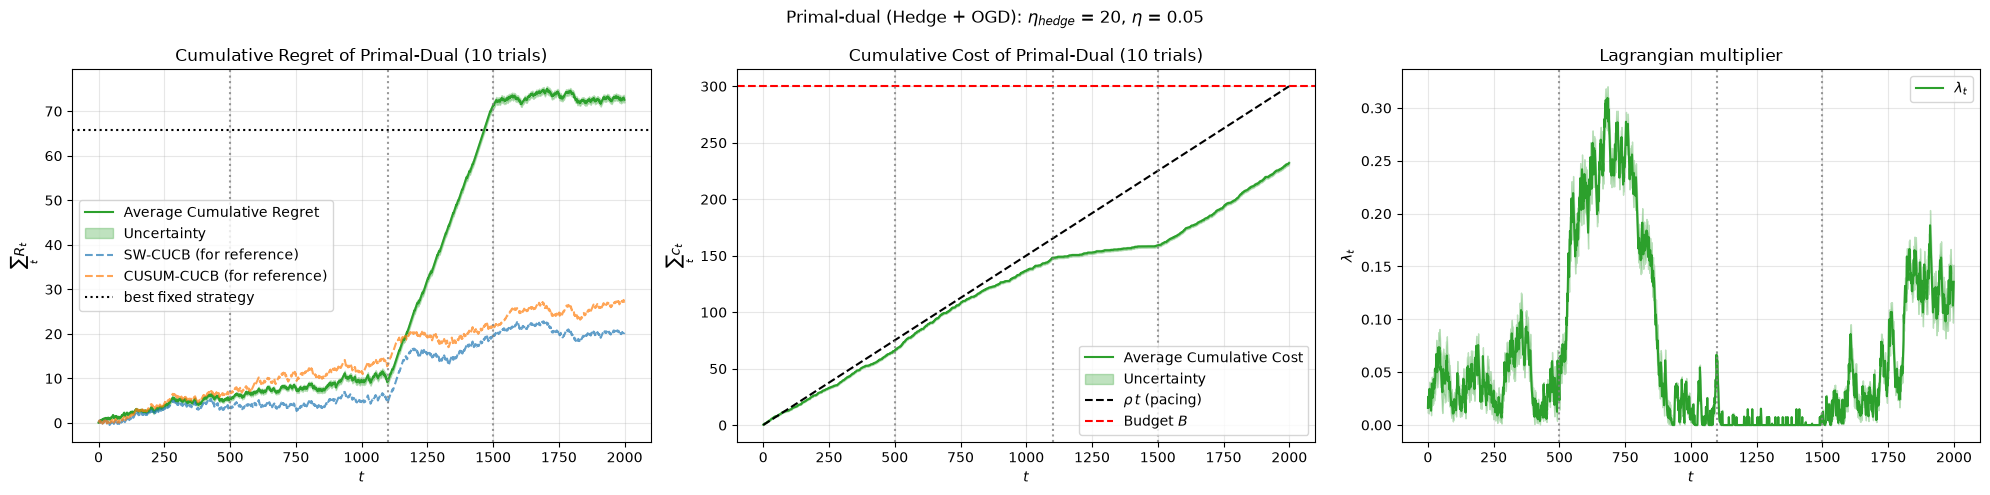

In [66]:
# --- Cumulative regret, cumulative cost and lambda_t of primal-dual ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(rounds, avg_regret_pd, color="C2", label="Average Cumulative Regret")
axes[0].fill_between(rounds,
                     avg_regret_pd - std_regret_pd / np.sqrt(n_trials),
                     avg_regret_pd + std_regret_pd / np.sqrt(n_trials),
                     color="C2", alpha=0.3, label="Uncertainty")
axes[0].plot(rounds, avg_regret, color="C0", linestyle="--", alpha=0.7, label="SW-CUCB (for reference)")
axes[0].plot(rounds, avg_regret_cusum, color="C1", linestyle="--", alpha=0.7, label="CUSUM-CUCB (for reference)")
axes[0].axhline(OPT_policy - OPT_fixed, color="black", linestyle=":",
                label="best fixed strategy")
for tau in breakpoints[1:-1]:
    axes[0].axvline(tau, color="gray", linestyle=":", alpha=0.8)
axes[0].set_xlabel("$t$")
axes[0].set_ylabel(r"$\sum_t R_t$")
axes[0].set_title(f"Cumulative Regret of Primal-Dual ({n_trials} trials)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rounds, avg_cost_pd, color="C2", label="Average Cumulative Cost")
axes[1].fill_between(rounds,
                     avg_cost_pd - std_cost_pd / np.sqrt(n_trials),
                     avg_cost_pd + std_cost_pd / np.sqrt(n_trials),
                     color="C2", alpha=0.3, label="Uncertainty")
axes[1].plot(rounds, rho * (rounds + 1), "k--", label=r"$\rho\, t$ (pacing)")
axes[1].axhline(B, color="red", linestyle="--", label="Budget $B$")
for tau in breakpoints[1:-1]:
    axes[1].axvline(tau, color="gray", linestyle=":", alpha=0.8)
axes[1].set_xlabel("$t$")
axes[1].set_ylabel(r"$\sum_t c_t$")
axes[1].set_title(f"Cumulative Cost of Primal-Dual ({n_trials} trials)")
axes[1].legend()
axes[1].grid(alpha=0.3)

mean_l, std_l = lmbd_per_trial_pd.mean(axis=0), lmbd_per_trial_pd.std(axis=0)
axes[2].plot(rounds, mean_l, color="C2", label=r"$\lambda_t$")
axes[2].fill_between(rounds, mean_l - std_l / np.sqrt(n_trials), mean_l + std_l / np.sqrt(n_trials),
                     color="C2", alpha=0.3)
for tau in breakpoints[1:-1]:
    axes[2].axvline(tau, color="gray", linestyle=":", alpha=0.8)
axes[2].set_xlabel("$t$")
axes[2].set_ylabel(r"$\lambda_t$")
axes[2].set_title("Lagrangian multiplier")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle(f"Primal-dual (Hedge + OGD): $\\eta_{{hedge}}$ = {hedge_eta}, $\\eta$ = {eta}")
plt.tight_layout()
plt.show()

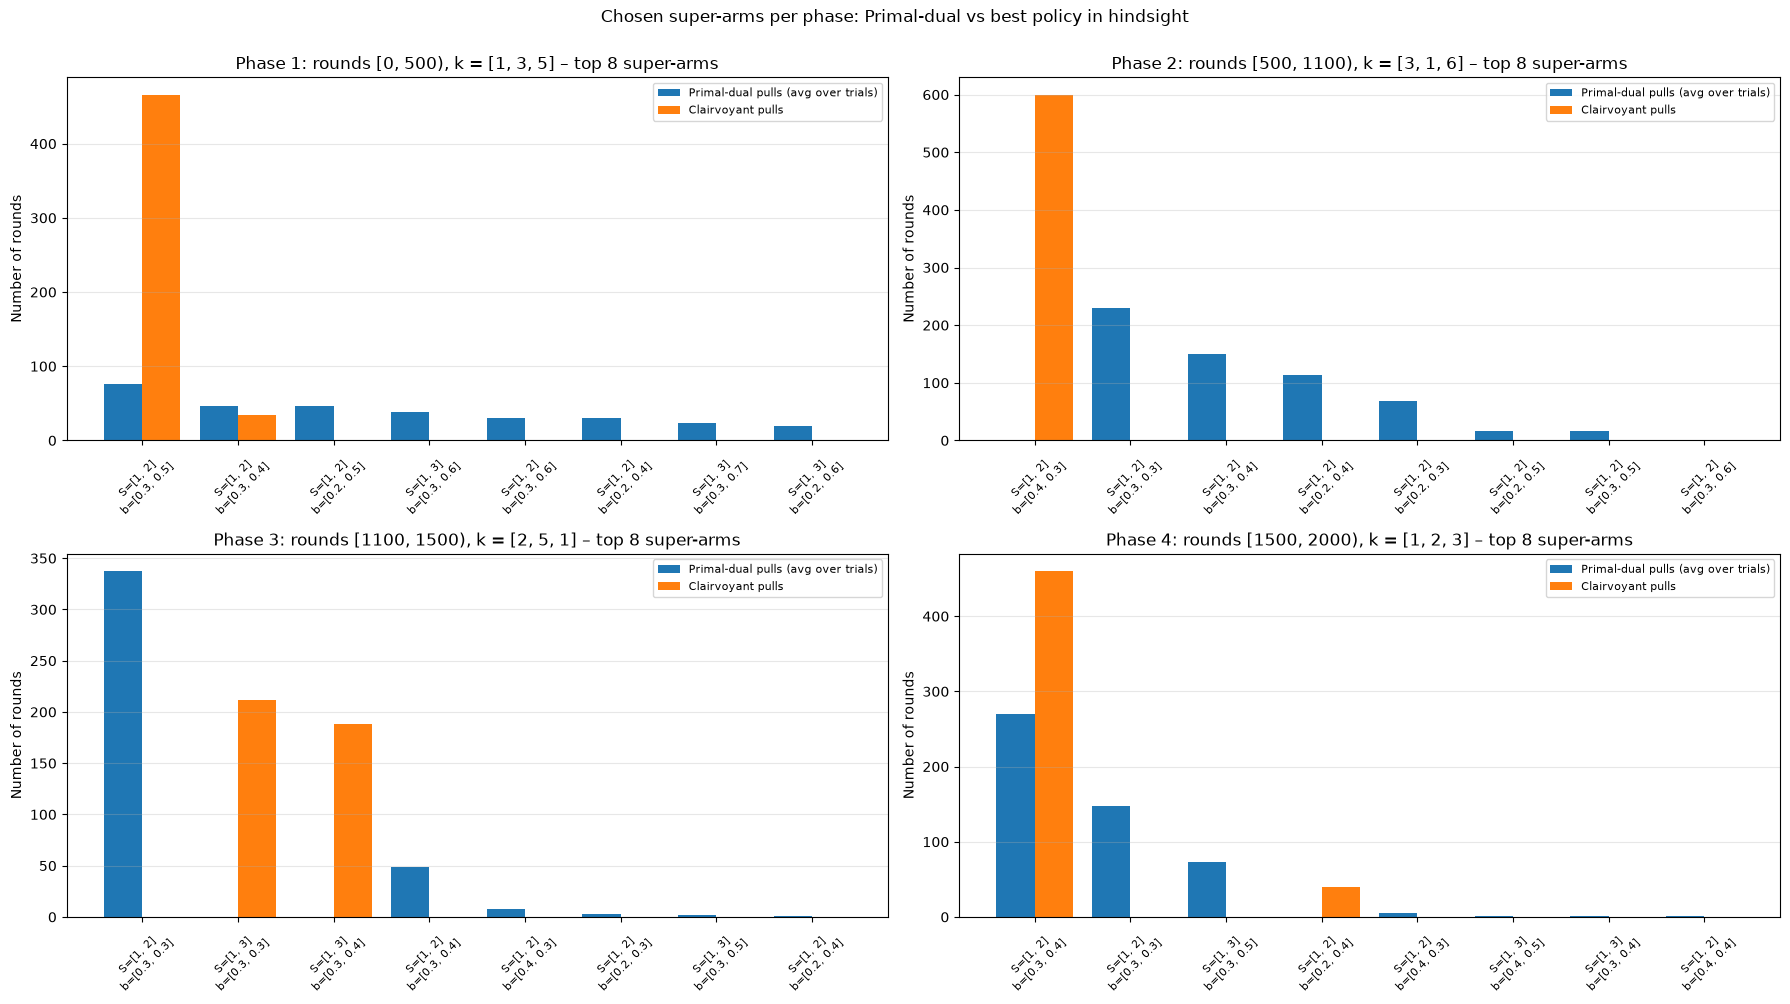

In [67]:
plot_pulls_per_phase(super_arm_per_trial_pd, "Primal-dual")